In [42]:
import astropy
import astroquery.simbad
import numpy as np
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
from astropy.coordinates import SkyCoord
import pyarrow
import pyvo
from astroquery.simbad import Simbad
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
from collections import Counter
import timeit
import matplotlib.pyplot as plt
import pandas
import os
import numpy.ma as ma

In [43]:
%load_ext autoreload
%autoreload 1
%aimport crossmatching
from crossmatching import Crossmatcher
from crossmatching import add_coord_epoch_column, allowed_angular_seperation, allowed_3d_seperation


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
cm = Crossmatcher()
cm.load_catalog(from_file="pscomppars.txt")
input_t = ascii.read("./input/HPIC_LC4_combined_d50.txt")
name_list = input_t["star_name"]  
_ = cm.load_alternate_ids(name_list, from_file="alternate_ids.txt")

In [45]:
set(cm.coordinate_crossmatch(input_t)[0].keys()) - set(cm.coordinate_crossmatch(input_t)[1].keys())
# yay 

{'3d_sep'}

In [46]:
set(cm.coordinate_crossmatch(input_t)[0].keys()) - set(cm.id_crossmatch(input_t).keys())

{'3d_sep'}

In [47]:
set(cm.id_crossmatch(input_t).keys()) - set(cm.coordinate_crossmatch(input_t)[0].keys())

{'id', 'input_ids'}

In [48]:
combined = cm.combined_crossmatch(input_t)

In [49]:
set(combined["ra_reflink"])

{np.str_('<a refstr=ARZOUMANIAN_ET_AL__1996 href=https://ui.adsabs.harvard.edu/abs/1996ASPC..105..525A/abstract target=ref> Arzoumanian et al. 1996 </a>'),
 np.str_('<a refstr=CALCHI_NOVATI_ET_AL__2018 href=https://ui.adsabs.harvard.edu/abs/2018AJ....155..261C/abstract target=ref>Calchi Novati et al. 2018</a>'),
 np.str_('<a refstr=HAN_ET_AL__2020 href=https://ui.adsabs.harvard.edu/abs/2020AJ....159...91H/abstract target=ref>Han et al. 2020</a>'),
 np.str_('<a refstr=LEWIN__AMP__JOSS_1981 href=https://ui.adsabs.harvard.edu/abs/1981SSRv...28....3L/abstract target=ref>Lewin &amp; Joss 1981</a>'),
 np.str_('<a refstr=STASSUN_ET_AL__2019 href=https://ui.adsabs.harvard.edu/abs/2019AJ....158..138S/abstract target=ref>TICv8</a>'),
 np.str_('<a refstr=VLEESCHOWER_ET_AL_2024 href=https://ui.adsabs.harvard.edu/abs/2024MNRAS.530.1436V/abstract target=ref>Vleeschower et al. 2024</a>'),
 np.str_('<a refstr=WENGER_ET_AL__2000 href=https://ui.adsabs.harvard.edu/abs/2000A&AS..143....9W/abstract target

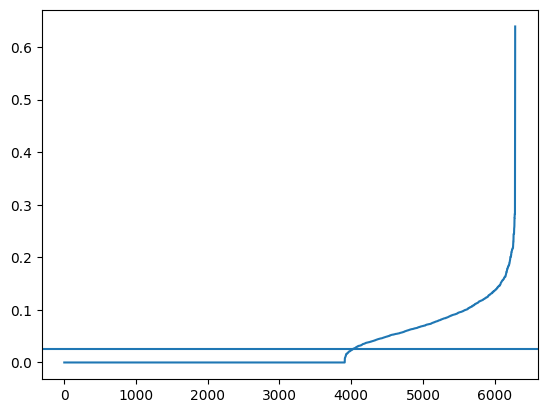

In [50]:
add_coord_epoch_column(cm.catalogue)
cm.catalogue["allowed_sep"] = allowed_angular_seperation(cm.catalogue["sy_pm"].filled(0)/1000, cm.catalogue["coord_epoch"], minimum=0)
# y = np.sort(cm.catalogue["allowed_sep"])
# c = 3
# plt.plot(y[y>c])
# len(y[y>c])

cm.catalogue["allowed_3d_sep"] = allowed_3d_seperation(
    cm.catalogue["allowed_sep"], 
    cm.catalogue["st_radv"], 
    cm.catalogue["sy_dist"],
    cm.catalogue["coord_epoch"],
    minimum = 0    
)

z = np.sort(cm.catalogue["allowed_3d_sep"]*10)
plt.plot(z)
plt.axhline(0.025)

In [51]:
pl

NameError: name 'pl' is not defined

In [ ]:
print(len(set(cm.id_matched["pl_name"])), len(cm.id_matched))
# good this means that every planet is unique
print(len(set(cm.id_matched["star_name"])))  
print(len(set(cm.id_matched["hostname"])))
print(len(input_t), len(set(input_t["star_name"])))
# alright input contains a duplicate
# so in short, we expect a lot of systmes to be matched with multiple planets

In [ ]:
print(len(set(cm.id_matched["pl_name"])), len(cm.id_matched))
print(len(input_t), len(set(input_t["star_name"])))
# planets 

In [ ]:
len(cm.matched)

In [ ]:
Counter(cm.matched["match_type"])

In [ ]:
plt.plot(np.sort(cm.matched["2d_sep"]), '.')

In [ ]:
plt.plot(np.sort(cm.matched["3d_sep"]), '.')

In [ ]:
Counter(cm.catalogue["pl_name"])

In [ ]:
final = cm.combined_crossmatch(input_t)
print(len(cm.id_matched))
print(len(cm.coords3d_matched))
print(len(cm.coords2d_matched))
print(Counter(final["match_type"]))
print(len(final), len(set(final["pl_name"]))) # this shouldn't happen
# final["pl_name", "match_type"]].to_pandas().sort_values("pl_name").to_csv("final_crossmatch.csv", index=False)
# final["pl_name", "match_type"].to_pandas().groupby("pl_name").count().sort_values("match_type", ascending=False)
final["pl_name", "star_name", "hostname", "id", "match_type"][np.isin(final["pl_name"], ["HD 46375 b", "DS Tuc A b",  "GJ 887 b", "GJ 887 c", "GJ 887 d"])]
# we conclude that the combination might work, but both methods can produce duplicates, need to further investigate why

In [ ]:
Counter(cm.alternate_ids["id"].data.data)

In [ ]:
cm.alternate_ids[cm.alternate_ids["id"].data.data == "0"]

In [ ]:
# look at "invalid" entries
alt_ids = cm.alternate_ids["id"]
cm.alternate_ids[alt_ids.mask]

In [ ]:
# input_plus_1alt = input_t.copy()
# input_plus_1alt.add_row({"star_name": "GJ 702 A"})
# input_plus_1alt[-1]
# cm.load_alternate_ids(input_plus_1alt["star_name"])

In [ ]:
# cm.alternate_ids.write("alternate_ids_1dupe.txt", format="ascii")

In [ ]:
# cm.load_alternate_ids(input_plus_1alt["star_name"], from_file="alternate_ids_1dupe.txt")

In [ ]:
# dupes = cm.find_duplicates(input_plus_1alt)
# dupes.pprint_all()

In [ ]:
# cm.alternate_ids

In [ ]:
cm.load_alternate_ids(input_t["star_name"], from_file="alternate_ids.txt")
nodupes = cm.remove_duplicates(input_t)

In [ ]:
nodupes
coords = SkyCoord(
    ra=nodupes["ra"]*u.deg,
    dec=nodupes["dec"]*u.deg,
    distance=nodupes["sy_dist"]*u.pc
)


idx2d, sep2d, _ = coords.match_to_catalog_sky(coords, nthneighbor=2)
idx3d, _, sep3d = coords.match_to_catalog_3d(coords, nthneighbor=2)
search_radius_arcsec = 1000*u.mas
search_radius_pc = 1*u.astronomical_unit # 0.005*u.pc
mask2d = sep2d <= search_radius_arcsec
mask3d = sep3d <= search_radius_pc
print("2D",np.sum(mask2d))
print("3D",np.sum(mask3d))
print("2D+ 3D",np.sum(mask2d & mask3d))

for i in range(len(idx2d)):
    if not mask2d[i]: continue 
    nodupes[[i, idx2d[i]]].pprint_all()

In [ ]:
np.sum(input_t["star_name"] == "TIC 1674663309")

In [ ]:
# input = ascii.read("./input/HPIC_LC4_combined_d50.txt")
# name_list = input["star_name"]

# print(np.sum(name_list == "TIC 1674663309")
# np.sum(input["star_name"] == "TIC 1674663309")

In [ ]:
np.argmax(np.zeros(10))

In [ ]:
list(input_t[25])

In [ ]:
np.isin(list(input_t[25]), [None, np.nan, "null", 0, '0']).sum()